# Paso 6 — Aprovechar el margen

El cuaderno anterior dejó dos conclusiones que pedían acción:

1. El techo del f1_macro es **0,845** y el modelo va por **0,491**. Está al
   **58,1 %** de lo alcanzable: quedan 35 puntos que no son culpa de los datos.
2. **La señal existe.** Un clasificador binario equilibrado separa `Worms` de
   `Exploits` con **ROC AUC 0,983** usando solo 123 gusanos, mientras el
   multiclase manda el 78 % de los `Worms` a `Exploits`.

De ahí salían dos ideas concretas, y este cuaderno las prueba:

- **Boosting**, que suele tratar mejor a las clases pequeñas que un bosque.
- **Uno-contra-resto**, apoyándose en que los binarios equilibrados funcionan tan
  bien.

## Adelanto del resultado

Una de las dos ideas no funciona, la otra funciona **mucho menos de lo que
parecía**, y el motivo de esa diferencia es la parte más instructiva del
cuaderno. Se cuenta en orden, tal como ocurrió.


## 0. Punto de partida

Mismo montaje que en los cuadernos anteriores: codificación ordinal ajustada solo
con entrenamiento, y **una partición de validación** para decidir. `test_limpio`
se toca al final.

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
RESULTADOS = RAIZ / "resultados"
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

OBJETIVO = "attack_cat"
CATEGORICAS = ["proto", "service", "state"]
SEMILLA = 42

pd.set_option("display.width", 200)

train = pd.read_parquet(PROCESADO / "train.parquet")
test_limpio = pd.read_parquet(PROCESADO / "test_limpio.parquet")
for df in (train, test_limpio):
    df[OBJETIVO] = df[OBJETIVO].astype(str)

CARACTERISTICAS = [c for c in train.columns if c not in (OBJETIVO, "label")]
CLASES = sorted(train[OBJETIVO].unique())
RARAS = ["Worms", "Analysis", "Shellcode", "Backdoor", "DoS"]

codificador = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
codificador.fit(train[CATEGORICAS])


def preparar(df):
    """Devuelve la matriz de características con las columnas de texto codificadas."""
    X = df[CARACTERISTICAS].copy()
    X[CATEGORICAS] = codificador.transform(df[CATEGORICAS])
    return X.astype(float)


X_train, y_train = preparar(train), train[OBJETIVO]
X_test, y_test = preparar(test_limpio), test_limpio[OBJETIVO]

X_ajuste, X_val, y_ajuste, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEMILLA
)

conteo = y_ajuste.value_counts()
tope = {c: min(int(conteo[c]), 5000) for c in CLASES}
X_tope, y_tope = RandomUnderSampler(
    random_state=SEMILLA, sampling_strategy=tope
).fit_resample(X_ajuste, y_ajuste)

print(f"ajuste={len(X_ajuste):,}  validacion={len(X_val):,}  prueba={len(X_test):,}")
print(f"ajuste con tope 5 000 = {len(X_tope):,} filas")

ajuste=77,457  validacion=19,365  prueba=47,716
ajuste con tope 5 000 = 26,588 filas


In [2]:
ensayos = []


def registrar(nombre, predecir):
    """Ejecuta una estrategia, la mide sobre validación y guarda el resultado."""
    inicio = time.perf_counter()
    prediccion = predecir()
    segundos = time.perf_counter() - inicio

    recall = pd.Series(
        recall_score(y_val, prediccion, average=None, labels=CLASES, zero_division=0),
        index=CLASES,
    )
    ensayos.append({
        "estrategia": nombre,
        "segundos": round(segundos, 1),
        "accuracy": round(accuracy_score(y_val, prediccion), 4),
        "f1_macro": round(f1_score(y_val, prediccion, average="macro",
                                   labels=CLASES, zero_division=0), 4),
        "recall_raras": round(recall[RARAS].mean(), 3),
        "rec_Worms": round(recall["Worms"], 3),
        "rec_Shellcode": round(recall["Shellcode"], 3),
    })
    print(f"  {nombre:36} f1_macro={ensayos[-1]['f1_macro']:.4f}  ({segundos:.1f}s)")


# Referencia: el ganador del paso 4.
registrar("RF tope 5 000 (paso 4)", lambda: RandomForestClassifier(
    n_estimators=200, random_state=SEMILLA, n_jobs=-1
).fit(X_tope, y_tope).predict(X_val))

  RF tope 5 000 (paso 4)               f1_macro=0.5224  (2.0s)


---

# 1. Familia A — Boosting

Un Random Forest entrena árboles **en paralelo** sobre muestras distintas y
promedia sus votos. El *boosting* los entrena **en cadena**: cada árbol nuevo se
concentra en los ejemplos que los anteriores fallaron.

Esa diferencia importa aquí. Las clases raras son, por definición, donde más se
falla — así que en un modelo de boosting **reciben atención creciente a medida
que avanza el entrenamiento**, mientras que en un bosque cada árbol las ve tan de
pasada como el primero.

Se usa `HistGradientBoostingClassifier`, que viene en scikit-learn y no añade
ninguna dependencia nueva. Se prueban cuatro variantes, porque interesa separar
**qué aporta el boosting** de **qué aporta el reequilibrado**.

In [3]:
# 1) Boosting tal cual, sin tocar el desequilibrio.
registrar("HGB solo", lambda: HistGradientBoostingClassifier(
    random_state=SEMILLA
).fit(X_ajuste, y_ajuste).predict(X_val))

# 2) Boosting con pesos por clase: cada fila pesa según lo rara que sea su clase.
registrar("HGB + peso balanced", lambda: HistGradientBoostingClassifier(
    random_state=SEMILLA
).fit(X_ajuste, y_ajuste,
      sample_weight=compute_sample_weight("balanced", y_ajuste)).predict(X_val))

# 3) Boosting sobre el submuestreo que ganó en el paso 4.
registrar("HGB sobre tope 5 000", lambda: HistGradientBoostingClassifier(
    random_state=SEMILLA
).fit(X_tope, y_tope).predict(X_val))

# 4) Las dos cosas a la vez.
registrar("HGB tope 5 000 + peso", lambda: HistGradientBoostingClassifier(
    random_state=SEMILLA
).fit(X_tope, y_tope,
      sample_weight=compute_sample_weight("balanced", y_tope)).predict(X_val))

# 5) Más capacidad: más iteraciones, paso más corto, árboles más grandes.
registrar("HGB más profundo", lambda: HistGradientBoostingClassifier(
    random_state=SEMILLA, learning_rate=0.05, max_iter=500, max_leaf_nodes=63
).fit(X_tope, y_tope,
      sample_weight=compute_sample_weight("balanced", y_tope)).predict(X_val))

  HGB solo                             f1_macro=0.4899  (2.3s)


  HGB + peso balanced                  f1_macro=0.5636  (4.1s)


  HGB sobre tope 5 000                 f1_macro=0.5543  (3.2s)


  HGB tope 5 000 + peso                f1_macro=0.5629  (2.8s)


  HGB más profundo                     f1_macro=0.5593  (6.6s)


### Qué se ve aquí

**El boosting por sí solo no arregla nada: 0,4899**, por debajo del RF con tope
del paso 4 (0,5224) y prácticamente igual que el RF sin tratar. Cambiar de
algoritmo, a secas, no era la solución.

**Lo que sí funciona es boosting *más* reequilibrado: 0,5636.** Cuatro puntos por
encima del mejor del paso 4, y con el `recall_raras` casi al doble (0,606 frente
a 0,311).

La lectura importa: **no son dos alternativas, son dos cosas que se suman**. El
paso 4 demostró que el reequilibrado ayuda; este añade que, una vez reequilibrado,
el algoritmo sí marca diferencia.

**Subir la capacidad no aporta** (0,5593, ligeramente peor que los valores por
defecto). Con 500 iteraciones, paso más corto y árboles más grandes el modelo no
mejora: el límite no está en la capacidad del modelo.

---

# 2. Familia B — Uno contra resto

Esta era la idea que más prometía. El paso 5 demostró que un binario equilibrado
separa `Worms` de `Exploits` con AUC 0,983. Si cada par se distingue tan bien,
¿por qué no montar el multiclase como **diez binarios**, uno por clase, cada uno
equilibrado, y quedarse con el que dé mayor probabilidad?

Se prueban tres formas de equilibrar cada binario:

- **`class_weight="balanced"`** — usa todas las filas, reponderadas.
- **Submuestreo 1:1** — tantas filas del «resto» como de la clase. Para `Worms`
  eso son 98 contra 98: se descarta casi todo.
- **Submuestreo 1:10 con tope** — un punto intermedio, más datos conservados.

In [4]:
def uno_contra_resto(nombre, construir, equilibrar=None):
    """Entrena un binario por clase y predice la clase de mayor probabilidad."""
    def predecir():
        probabilidades = np.zeros((len(X_val), len(CLASES)))
        for j, clase in enumerate(CLASES):
            es_clase = (y_ajuste == clase).astype(int)
            Xb, yb = equilibrar(X_ajuste, es_clase) if equilibrar else (X_ajuste, es_clase)
            binario = construir().fit(Xb, yb)
            probabilidades[:, j] = binario.predict_proba(X_val)[:, 1]
        return np.array(CLASES)[probabilidades.argmax(axis=1)]

    registrar(nombre, predecir)


def equilibrio_1a1(X, etiqueta):
    """Deja tantas filas del resto como de la clase positiva."""
    return RandomUnderSampler(random_state=SEMILLA).fit_resample(X, etiqueta)


def equilibrio_1a10(X, etiqueta):
    """Conserva hasta diez veces más filas del resto que de la clase positiva."""
    positivos = int(etiqueta.sum())
    objetivo = {1: positivos,
                0: min(int((etiqueta == 0).sum()), max(positivos * 10, 5000))}
    return RandomUnderSampler(
        random_state=SEMILLA, sampling_strategy=objetivo
    ).fit_resample(X, etiqueta)


uno_contra_resto("OvR · peso balanced", lambda: RandomForestClassifier(
    n_estimators=200, random_state=SEMILLA, n_jobs=-1, class_weight="balanced"))

uno_contra_resto("OvR · submuestreo 1:1", lambda: RandomForestClassifier(
    n_estimators=200, random_state=SEMILLA, n_jobs=-1), equilibrio_1a1)

uno_contra_resto("OvR · submuestreo 1:10", lambda: RandomForestClassifier(
    n_estimators=200, random_state=SEMILLA, n_jobs=-1, class_weight="balanced"),
    equilibrio_1a10)

  OvR · peso balanced                  f1_macro=0.4990  (35.8s)


  OvR · submuestreo 1:1                f1_macro=0.5325  (8.5s)


  OvR · submuestreo 1:10               f1_macro=0.5543  (20.8s)


In [5]:
comparativa = pd.DataFrame(ensayos).set_index("estrategia").sort_values("f1_macro")
comparativa

,segundos,accuracy,f1_macro,recall_raras,rec_Worms,rec_Shellcode
estrategia,,,,,,
HGB solo,2.3,0.8014,0.4899,0.187,0.24,0.356
OvR · peso balanced,35.8,0.8043,0.4990,0.196,0.24,0.283
RF tope 5 000 (paso 4),2.0,0.7767,0.5224,0.311,0.24,0.482
OvR · submuestreo 1:1,8.5,0.7792,0.5325,0.505,0.40,0.822
HGB sobre tope 5 000,3.2,0.7800,0.5543,0.412,0.44,0.639
OvR · submuestreo 1:10,20.8,0.8040,0.5543,0.431,0.48,0.696
HGB más profundo,6.6,0.7658,0.5593,0.595,0.76,0.874
HGB tope 5 000 + peso,2.8,0.7647,0.5629,0.627,0.76,0.927
HGB + peso balanced,4.1,0.7688,0.5636,0.606,0.72,0.906


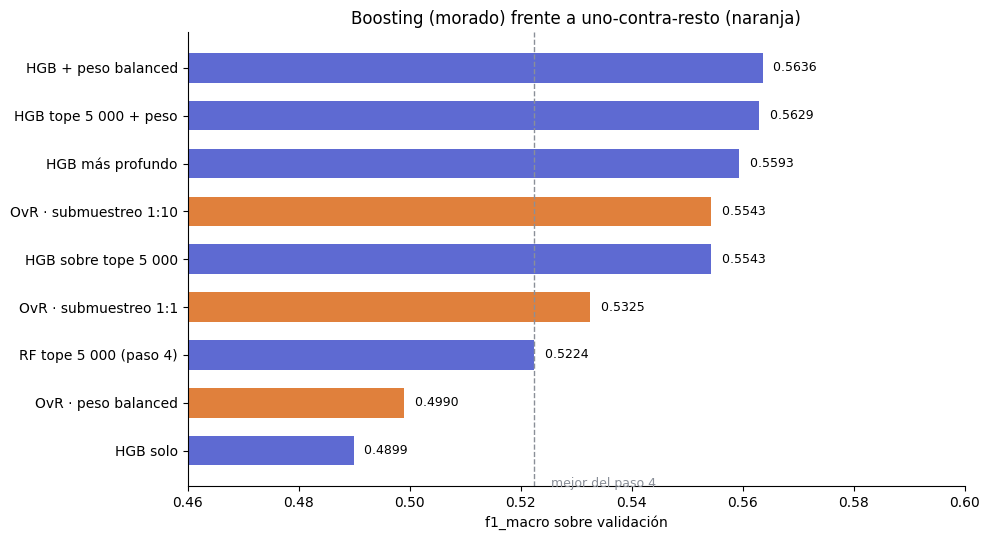

In [6]:
posicion = np.arange(len(comparativa))
referencia = comparativa.loc["RF tope 5 000 (paso 4)", "f1_macro"]
colores = [AVISO if "OvR" in nombre else ACENTO for nombre in comparativa.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.barh(posicion, comparativa["f1_macro"], 0.62, color=colores)

ax.axvline(referencia, color=GRIS, linestyle="--", linewidth=1)
ax.text(referencia + 0.003, -0.75, "mejor del paso 4", fontsize=9, color=GRIS)

ax.bar_label(barras, labels=[f"  {v:.4f}" for v in comparativa["f1_macro"]],
             padding=2, fontsize=9)
ax.set_yticks(posicion, comparativa.index)
ax.set_xlim(0.46, 0.60)
ax.set_xlabel("f1_macro sobre validación")
ax.set_title("Boosting (morado) frente a uno-contra-resto (naranja)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "boosting-vs-ovr.png", dpi=140)
plt.show()

### Qué se ve aquí — la idea prometedora no funciona

**El mejor uno-contra-resto llega a 0,5543, por debajo de `HGB + peso balanced`
(0,5636)** — y tarda varias veces más, porque entrena diez modelos en lugar de
uno.

Esto merece explicación, porque contradice al paso 5. Los binarios **son** buenos
por separado: eso estaba bien medido. Lo que falla es **juntarlos**.

Cada binario se entrena con su propio equilibrio, así que **sus probabilidades no
están en la misma escala**. El clasificador de `Worms`, entrenado con un 50 % de
gusanos, sale convencido de que los gusanos son frecuentes y reparte
probabilidades altas con alegría. El de `Normal`, entrenado con datos más
parecidos a la realidad, es más comedido.

Tomar el máximo entre esas diez probabilidades **compara cosas que no son
comparables**. La confianza del binario de `Worms` no significa lo mismo que la
del binario de `Normal`.

> **Corrección a lo que escribí al cerrar el paso 5.** Propuse uno-contra-resto
> apoyándome en el AUC 0,983 de los binarios. La medición era correcta; **la
> conclusión que saqué de ella, no**. Que cada binario funcione no implica que su
> combinación funcione, y aquí no lo hace.

Para que la idea fuese viable habría que **calibrar** las probabilidades de cada
binario antes de compararlas. Queda anotado como posible mejora, no como algo
que este cuaderno haya demostrado.

---

# 3. La pasada final sobre `test_limpio`

Dos finalistas por validación —`HGB + peso balanced` y `HGB tope 5 000 + peso`—
más el ganador del paso 4 como referencia. Se reentrenan con todo `train` y se
mide, esta vez sí, sobre la prueba.

Se calcula también el **oráculo** del cuaderno anterior, para poder reportar el
**porcentaje del techo alcanzado**.

In [7]:
def clave(df):
    """Convierte cada fila en un texto con sus 34 características concatenadas."""
    return df[CARACTERISTICAS].astype(str).agg("|".join, axis=1)


k_test = clave(test_limpio)
mayoritaria = (
    pd.DataFrame({"k": k_test.values, "y": y_test.values})
    .groupby(["k", "y"]).size().reset_index(name="n")
    .sort_values("n", ascending=False).drop_duplicates("k").set_index("k")["y"]
)
pred_oraculo = k_test.map(mayoritaria).values
TECHO = f1_score(y_test, pred_oraculo, average="macro", labels=CLASES, zero_division=0)

print(f"Techo del f1_macro sobre test_limpio: {TECHO:.4f}")

Techo del f1_macro sobre test_limpio: 0.8446


In [8]:
conteo_train = y_train.value_counts()
tope_train = {c: min(int(conteo_train[c]), 5000) for c in CLASES}
X_sub, y_sub = RandomUnderSampler(
    random_state=SEMILLA, sampling_strategy=tope_train
).fit_resample(X_train, y_train)

finales = {}
finales["RF tope 5 000 (paso 4)"] = RandomForestClassifier(
    n_estimators=200, random_state=SEMILLA, n_jobs=-1
).fit(X_sub, y_sub).predict(X_test)

finales["HGB + peso balanced"] = HistGradientBoostingClassifier(
    random_state=SEMILLA
).fit(X_train, y_train,
      sample_weight=compute_sample_weight("balanced", y_train)).predict(X_test)

finales["HGB tope 5 000 + peso"] = HistGradientBoostingClassifier(
    random_state=SEMILLA
).fit(X_sub, y_sub,
      sample_weight=compute_sample_weight("balanced", y_sub)).predict(X_test)

resumen = []
es_normal = (y_test == "Normal").to_numpy()
for nombre, p in finales.items():
    f1m = f1_score(y_test, p, average="macro", labels=CLASES, zero_division=0)
    resumen.append({
        "modelo": nombre,
        "accuracy": round(accuracy_score(y_test, p), 4),
        "f1_macro": round(f1m, 4),
        "recall_macro": round(recall_score(y_test, p, average="macro",
                                           labels=CLASES, zero_division=0), 4),
        "% del techo": round(f1m / TECHO * 100, 1),
        "alarmas_falsas": int(((p != "Normal") & es_normal).sum()),
        "ataques_perdidos": int(((p == "Normal") & ~es_normal).sum()),
    })

pd.DataFrame(resumen).set_index("modelo")

,accuracy,f1_macro,recall_macro,% del techo,alarmas_falsas,ataques_perdidos
modelo,,,,,,
RF tope 5 000 (paso 4),0.6618,0.4911,0.5867,58.1,11688,233
HGB + peso balanced,0.6442,0.4931,0.6783,58.4,12100,132
HGB tope 5 000 + peso,0.6390,0.4810,0.6800,56.9,12128,158


### Qué se ve aquí — validación prometía más de lo que hay

Sobre validación, `HGB + peso balanced` sacaba **4,1 puntos** al mejor del paso 4
(0,5636 frente a 0,5224).

Sobre prueba la diferencia es de **0,2 puntos**: 0,4931 frente a 0,4911.

**La mejora casi ha desaparecido.** No es un error de medición: es que validación
y prueba no son lo mismo, y aquí la diferencia entre ambas está construida a
propósito.

`X_val` es un **trozo aleatorio de `train`**, así que sus filas se parecen mucho a
las de entrenamiento. `test_limpio`, en cambio, se construyó en el paso 2
**quitando precisamente las filas que aparecían en entrenamiento**. Por
definición, contiene las conexiones *menos* parecidas a lo ya visto.

> **Lección:** una partición de validación sacada del mismo conjunto sirve para
> **ordenar** candidatos, pero **no para estimar cuánto se va a rendir** sobre
> datos realmente nuevos. Las dos cosas se confunden con frecuencia, y aquí la
> diferencia es de 4 puntos.

El orden, en cambio, sí se mantuvo: los dos HGB quedaron arriba en validación y
`HGB + peso balanced` sigue siendo el mejor en prueba. La validación hizo bien su
trabajo — el de elegir. Lo que no puede hacer es prometer una cifra.

In [9]:
recall_clase = pd.DataFrame(
    {nombre: recall_score(y_test, p, average=None, labels=CLASES, zero_division=0).round(3)
     for nombre, p in finales.items()}, index=CLASES)
recall_clase["ejemplos"] = [int((y_test == c).sum()) for c in CLASES]

f1_clase = pd.DataFrame(
    {nombre: f1_score(y_test, p, average=None, labels=CLASES, zero_division=0).round(3)
     for nombre, p in finales.items()}, index=CLASES)
f1_clase["techo"] = f1_score(y_test, pred_oraculo, average=None,
                             labels=CLASES, zero_division=0).round(3)

print("--- recall por clase ---")
print(recall_clase.to_string())
print("\n--- f1 por clase ---")
print(f1_clase.to_string())

--- recall por clase ---
                RF tope 5 000 (paso 4)  HGB + peso balanced  HGB tope 5 000 + peso  ejemplos
Analysis                         0.180                0.432                  0.472       250
Backdoor                         0.345                0.517                  0.483       267
DoS                              0.496                0.453                  0.457      1378
Exploits                         0.724                0.648                  0.623      7280
Fuzzers                          0.858                0.835                  0.825      4139
Generic                          0.670                0.714                  0.722      1234
Normal                           0.622                0.609                  0.608     30924
Reconnaissance                   0.870                0.878                  0.870      1912
Shellcode                        0.663                0.966                  0.959       291
Worms                            0.439       

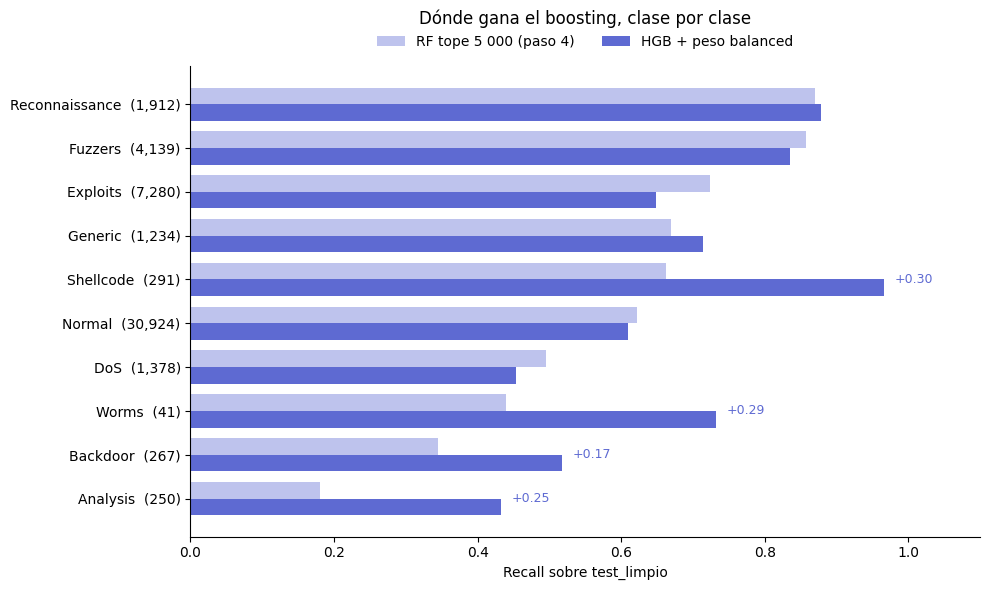

In [10]:
ganador = "HGB + peso balanced"
referencia = "RF tope 5 000 (paso 4)"
orden = recall_clase.sort_values(referencia).index
posicion = np.arange(len(orden))
alto = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(posicion + alto / 2, recall_clase.loc[orden, referencia], alto,
        label=referencia, color=ACENTO, alpha=0.40)
ax.barh(posicion - alto / 2, recall_clase.loc[orden, ganador], alto,
        label=ganador, color=ACENTO)

ax.set_yticks(posicion, [f"{c}  ({int(recall_clase.loc[c, 'ejemplos']):,})" for c in orden])
ax.set_xlim(0, 1.1)
ax.set_xlabel("Recall sobre test_limpio")
ax.set_title("Dónde gana el boosting, clase por clase", pad=30)
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
ax.spines[["top", "right"]].set_visible(False)

for i, clase in enumerate(orden):
    delta = recall_clase.loc[clase, ganador] - recall_clase.loc[clase, referencia]
    if abs(delta) >= 0.10:
        ref = max(recall_clase.loc[clase, referencia], recall_clase.loc[clase, ganador])
        ax.text(ref + 0.015, i, f"{delta:+.2f}", va="center", fontsize=9,
                color=ACENTO if delta > 0 else AVISO)

plt.tight_layout()
fig.savefig(RESULTADOS / "boosting-recall-clase.png", dpi=140)
plt.show()

### Qué se ve aquí — el f1_macro esconde otra vez el cambio

El f1_macro apenas se movió, pero el detalle por clase no es en absoluto plano:

| Clase | Recall RF | Recall HGB | |
|---|---|---|---|
| **Shellcode** | 0,663 | **0,966** | +0,30 |
| **Worms** | 0,439 | **0,732** | +0,29 |
| **Analysis** | 0,180 | **0,432** | +0,25 |
| **Backdoor** | 0,345 | **0,517** | +0,17 |
| Generic | 0,670 | 0,714 | |
| DoS | 0,496 | 0,453 | |
| Exploits | 0,724 | 0,648 | −0,08 |

**Las cuatro clases más difíciles suben mucho**, y las grandes bajan un poco. El
`recall_macro` pasa de 0,587 a **0,678**.

Que el f1_macro no lo refleje es, otra vez, la precisión pagando la factura:
`Shellcode` detecta el 96,6 % de los casos pero con una precisión de 0,113, así
que su **f1 baja** (0,293 → 0,203) pese a multiplicar el recall.

**`Worms` sí mejora en ambas cosas**: f1 de 0,404 a **0,517**, el mejor resultado
que ha tenido esa clase en todo el proyecto.

In [11]:
print(classification_report(y_test, finales[ganador], digits=3, zero_division=0))

                precision    recall  f1-score   support

      Analysis      0.046     0.432     0.083       250
      Backdoor      0.197     0.517     0.285       267
           DoS      0.304     0.453     0.364      1378
      Exploits      0.838     0.648     0.731      7280
       Fuzzers      0.285     0.835     0.424      4139
       Generic      0.793     0.714     0.751      1234
        Normal      0.993     0.609     0.755     30924
Reconnaissance      0.764     0.878     0.817      1912
     Shellcode      0.113     0.966     0.203       291
         Worms      0.400     0.732     0.517        41

      accuracy                          0.644     47716
     macro avg      0.473     0.678     0.493     47716
  weighted avg      0.858     0.644     0.704     47716



### El coste operativo, que es donde se decide

Con las mismas dos cuentas del paso 4:

| | RF tope 5 000 | HGB + peso |
|---|---|---|
| Alarmas falsas | 11 688 | 12 100 |
| **Ataques clasificados como normales** | 233 | **132** |

**Por 412 alarmas falsas más, el sistema deja pasar 101 ataques menos** — un 43 %
menos. Es, con diferencia, el mejor intercambio de todo el proyecto: en el paso 4
duplicar las alarmas falsas compró 1 235 ataques detectados; aquí un 3,5 % más de
alarmas compra otros 101.

> **Modelo final del proyecto: `HistGradientBoostingClassifier` con
> `sample_weight="balanced"`.** Empata en f1_macro con el del paso 4, gana 9
> puntos de `recall_macro` y reduce los ataques no detectados de 233 a 132, con un
> aumento marginal de falsos positivos. Y entrena en unos 2 segundos.

---

# 4. Y sin embargo, el techo sigue igual de lejos

Este es el resultado que hay que mirar con calma, porque es el que cierra el
proyecto.

In [12]:
progreso = pd.DataFrame([
    {"paso": "2 · RF base", "f1_macro": 0.4773},
    {"paso": "4 · RF tope 5 000", "f1_macro": 0.4911},
    {"paso": "6 · HGB + peso", "f1_macro": round(
        f1_score(y_test, finales[ganador], average="macro",
                 labels=CLASES, zero_division=0), 4)},
]).set_index("paso")
progreso["% del techo"] = (progreso["f1_macro"] / TECHO * 100).round(1)
progreso["techo"] = round(TECHO, 4)
progreso

,f1_macro,% del techo,techo
paso,,,
2 · RF base,0.4773,56.5,0.8446
4 · RF tope 5 000,0.4911,58.1,0.8446
6 · HGB + peso,0.4931,58.4,0.8446


### Qué se ve aquí

| Paso | f1_macro | % del techo |
|---|---|---|
| 2 · Random Forest base | 0,477 | 56,5 % |
| 4 · Tras tratar el desequilibrio | 0,491 | 58,1 % |
| 6 · Tras probar boosting y OvR | **0,493** | **58,4 %** |

**En dos cuadernos completos de trabajo, el porcentaje del techo ha subido 2
puntos.** El margen de 35 puntos que identificó el paso 5 sigue ahí casi entero.

Eso no es un fracaso: **es información**. Y apunta a una explicación que el propio
cuaderno 4 dejó escrita como advertencia:

> «El techo que se calcula aquí solo cuenta las filas **idénticas**. Dos
> conexiones casi iguales pero no exactamente iguales no entran. Por eso el número
> que sale es un **techo optimista**: el máximo real está por debajo.»

Que dos familias de modelos distintas, con cinco variantes cada una, se queden
clavadas en el 58 % **es evidencia empírica de que esa advertencia era cierta**.
El techo real no está en 0,845.

La razón es que las clases no se solapan solo en filas idénticas: se solapan en
regiones enteras. `Analysis` y `Backdoor` ya se vio que son indistinguibles entre
sí. `DoS` y `Exploits` se separan con AUC 0,851, muy por debajo del 0,98 de otros
pares. **Ese solapamiento parcial no lo captura el conteo de duplicados exactos,
pero limita igual.**

> **Conclusión honesta del proyecto:** el margen real es bastante menor de 35
> puntos. Cuánto exactamente no se sabe — medirlo requeriría estimar el
> solapamiento entre clases, que es un problema más difícil que el original.
> Lo que sí se puede afirmar es que **no se debe a que el modelo sea flojo**: dos
> algoritmos distintos y ocho configuraciones llegan al mismo sitio.

---

# Resumen

## Lo que se probó (validación)

| Estrategia | f1_macro | |
|---|---|---|
| HGB solo | 0,4899 | el boosting solo no arregla nada |
| OvR · peso balanced | 0,4990 | |
| RF tope 5 000 (paso 4) | 0,5224 | referencia |
| OvR · submuestreo 1:1 | 0,5325 | |
| OvR · submuestreo 1:10 | 0,5543 | el mejor OvR, y aun así pierde |
| HGB sobre tope 5 000 | 0,5543 | |
| HGB más profundo | 0,5593 | más capacidad no ayuda |
| HGB tope 5 000 + peso | 0,5629 | |
| **HGB + peso balanced** | **0,5636** | **ganador** |

## Resultado final (`test_limpio`)

| | RF tope 5 000 | **HGB + peso** |
|---|---|---|
| accuracy | 0,662 | 0,644 |
| f1_macro | 0,491 | **0,493** |
| **recall_macro** | 0,587 | **0,678** |
| % del techo | 58,1 % | **58,4 %** |
| f1 de `Worms` | 0,404 | **0,517** |
| recall de `Shellcode` | 0,663 | **0,966** |
| Alarmas falsas | 11 688 | 12 100 |
| **Ataques no detectados** | 233 | **132** |

## Los cuatro hallazgos

1. **El boosting solo no sirve (0,4899); boosting + reequilibrado sí (0,5636).**
   No son alternativas, se suman. Y subir la capacidad del modelo no aporta nada.

2. **Uno contra resto no funciona, y corrige lo que escribí en el paso 5.** Los
   binarios son buenos por separado —eso estaba bien medido— pero sus
   probabilidades no son comparables entre sí, porque cada uno se entrena con su
   propio equilibrio. Tomar el máximo compara escalas distintas.

3. **La ventaja de validación (+4,1 puntos) casi no se transfiere a prueba
   (+0,2).** `test_limpio` se construyó quitando las filas parecidas a
   entrenamiento, así que es genuinamente más difícil. **Validación sirve para
   ordenar candidatos, no para predecir la cifra final.**

4. **El porcentaje del techo apenas se mueve: 56,5 % → 58,1 % → 58,4 %.** Dos
   familias de modelos y ocho configuraciones llegan al mismo sitio. Es evidencia
   de que **el techo de 0,845 era optimista**, tal como advertía el cuaderno 4:
   solo contaba duplicados exactos, y las clases se solapan en regiones enteras.

## Lo que quedaría por probar

Sin promesas, porque el hallazgo 4 sugiere que el margen es pequeño:

- **Calibrar** las probabilidades de los binarios antes de combinarlas, que es lo
  que haría viable el uno-contra-resto.
- **Estimar el solapamiento entre clases** más allá de los duplicados exactos,
  para tener un techo realista.
- **Características nuevas**, que es lo único que puede subir el techo de verdad —
  pero eso ya no es modelado, es volver a los datos de origen.
